# 05 - Unsupervised Learning

# Segmentación de operaciones logísticas mediante aprendizaje no supervisado

En este notebook se aplican técnicas de aprendizaje no supervisado para descubrir patrones naturales dentro de las operaciones logísticas.

A diferencia del aprendizaje supervisado, aquí no se busca predecir una variable objetivo específica.

El propósito principal es:

- identificar grupos naturales de envíos;
- descubrir patrones ocultos;
- segmentar operaciones logísticas;
- detectar perfiles operacionales similares;
- analizar estructuras internas del dataset.

Las técnicas utilizadas serán:

- PCA (Principal Component Analysis);
- KMeans Clustering;
- Método del codo;
- Visualización de clusters.

La pregunta principal es:

> ¿Qué grupos naturales existen dentro de las operaciones logísticas?


# Objetivos del notebook

En esta etapa del proyecto se busca:

- reducir dimensionalidad mediante PCA;
- visualizar relaciones complejas entre operaciones;
- encontrar clusters naturales de envíos;
- interpretar grupos logísticos;
- detectar operaciones de bajo y alto riesgo;
- analizar perfiles operacionales similares.

Este análisis complementa el enfoque supervisado realizado anteriormente.


# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


# 2. Carga del dataset

In [2]:
df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()


Dimensiones del dataset:
(998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


# 3. Variables utilizadas

Para clustering se utilizarán principalmente variables operacionales y variables creadas durante el feature engineering.

El objetivo es representar correctamente:

- carga;
- capacidad;
- distancia;
- velocidad;
- riesgo;
- exigencia operacional.


In [3]:
variables_cluster = [
    "distancia_km",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "peso_kg_log",
    "distancia_km_log",
    "velocidad_promedio_km_h_log",
    "riesgo_velocidad_log"
]

variables_cluster = [v for v in variables_cluster if v in df.columns]

print("Cantidad de variables:")
print(len(variables_cluster))

variables_cluster


Cantidad de variables:
19



[
    'distancia_km',
    'peso_kg',
    'volumen_m3',
    'capacidad_kg',
    'capacidad_m3',
    'velocidad_promedio_km_h',
    'km_recorridos',
    'uso_capacidad_kg_recalculado',
    'uso_capacidad_m3_recalculado',
    'densidad_carga',
    'riesgo_velocidad',
    'vehiculo_exigido',
    'sobrecarga_kg',
    'ruta_larga',
    'velocidad_alta',
    'peso_kg_log',
    'distancia_km_log',
    'velocidad_promedio_km_h_log',
    'riesgo_velocidad_log'
]

# 4. Preparación de datos

Antes de aplicar clustering:

- se imputan valores faltantes;
- se escalan variables;
- se prepara una matriz limpia para PCA y KMeans.

El escalamiento es importante porque KMeans es sensible a magnitudes distintas.


In [4]:
X = df[variables_cluster].copy()

variables_numericas = X.select_dtypes(include=np.number).columns.tolist()

pipeline_preprocesamiento = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_preparado = pipeline_preprocesamiento.fit_transform(X)

print("Shape final:")
print(X_preparado.shape)


Shape final:
(998, 19)


# 5. Reducción de dimensionalidad con PCA

PCA permite reducir la cantidad de dimensiones manteniendo la mayor cantidad posible de información.

Esto facilita:

- visualización;
- interpretación;
- clustering;
- detección de patrones.

En este caso se reducirá inicialmente a 2 componentes principales.


In [5]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_preparado)

print("Shape PCA:")
print(X_pca.shape)

print("\nVarianza explicada:")
print(pca.explained_variance_ratio_)

print("\nVarianza acumulada:")
print(np.sum(pca.explained_variance_ratio_))


Shape PCA:
(998, 2)

Varianza explicada:
[0.30982783 0.20088718]

Varianza acumulada:
0.5107150040393209


# 5.1 Visualización PCA

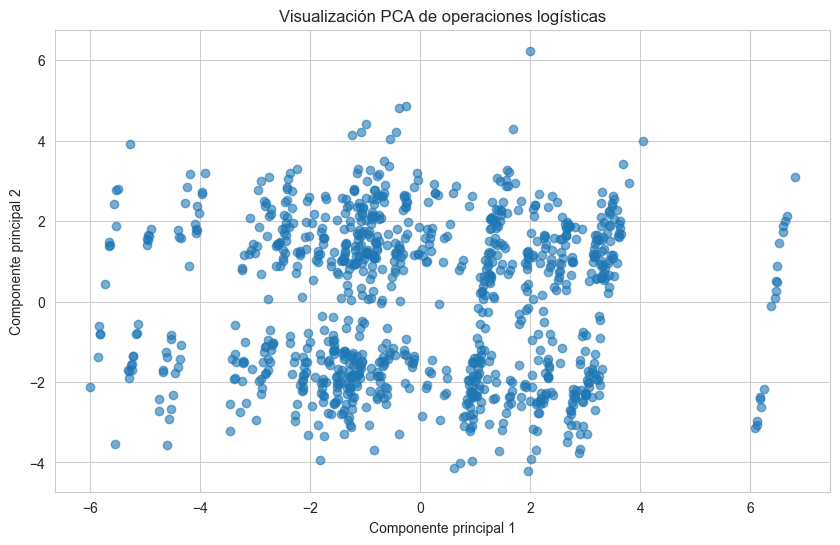

In [6]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.6
)

plt.title("Visualización PCA de operaciones logísticas")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

plt.show()


## Análisis PCA

El PCA permite observar si existen agrupaciones naturales dentro de los datos.

Si aparecen zonas densas o grupos separados, esto puede indicar la existencia de perfiles operacionales distintos.


# 6. Método del codo

Antes de aplicar KMeans, se utilizará el método del codo para estimar una cantidad adecuada de clusters.

Se evaluarán distintos valores de K.


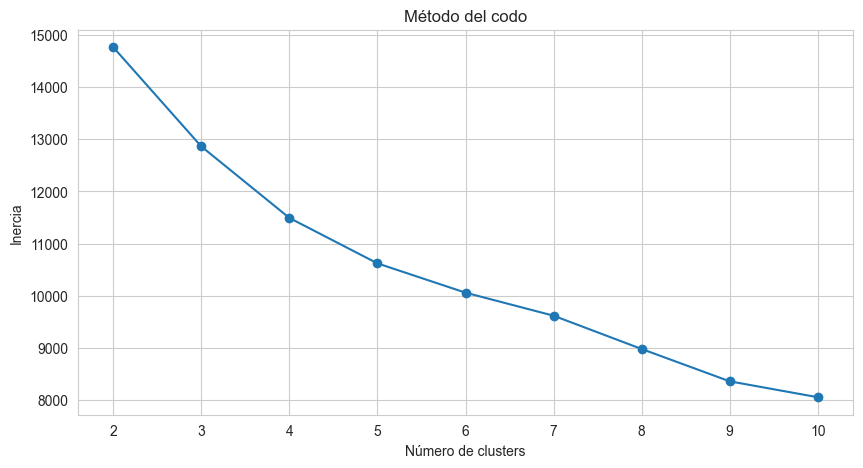

In [7]:
inercias = []

rango_k = range(2, 11)

for k in rango_k:

    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo_kmeans.fit(X_preparado)

    inercias.append(modelo_kmeans.inertia_)

plt.figure(figsize=(10,5))

plt.plot(rango_k, inercias, marker="o")

plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.show()


## Análisis del método del codo

El objetivo es encontrar un punto donde la reducción de inercia comienza a estabilizarse.

Ese punto representa un equilibrio entre:

- simplicidad;
- separación de clusters;
- capacidad explicativa.


# 7. Evaluación con Silhouette Score

Además del método del codo, se calculará el silhouette score.

Esta métrica mide qué tan separados y compactos están los clusters.


In [8]:
resultados_silhouette = []

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = modelo.fit_predict(X_preparado)

    score = silhouette_score(X_preparado, clusters)

    resultados_silhouette.append({
        "k": k,
        "silhouette_score": score
    })

df_silhouette = pd.DataFrame(resultados_silhouette)

df_silhouette


,k,silhouette_score
0,2,0.214536
1,3,0.190467
2,4,0.196488
3,5,0.196789
4,6,0.204447
5,7,0.200896
6,8,0.171870
7,9,0.188795
8,10,0.175798


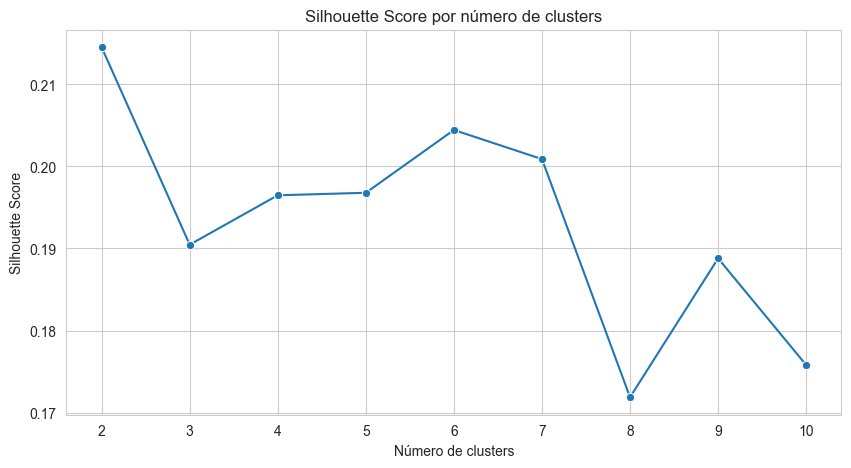

In [9]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_silhouette,
    x="k",
    y="silhouette_score",
    marker="o"
)

plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")

plt.show()


## Interpretación del silhouette score

Valores más altos indican:

- clusters mejor separados;
- menor mezcla entre grupos;
- estructuras más consistentes.

Con base en el método del codo y silhouette score se seleccionará un valor final de K.


# 8. Aplicación de KMeans

Se aplicará clustering usando el valor seleccionado de K.

Puedes modificar manualmente el valor si el análisis visual sugiere otra estructura.


In [10]:
k_final = 4

modelo_kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

clusters_finales = modelo_kmeans_final.fit_predict(X_preparado)

df["cluster"] = clusters_finales

print("Distribución de clusters:")
print(df["cluster"].value_counts())


Distribución de clusters:
cluster
0    305
3    259
2    238
1    196
Name: count, dtype: int64


# 8.1 Visualización de clusters en PCA

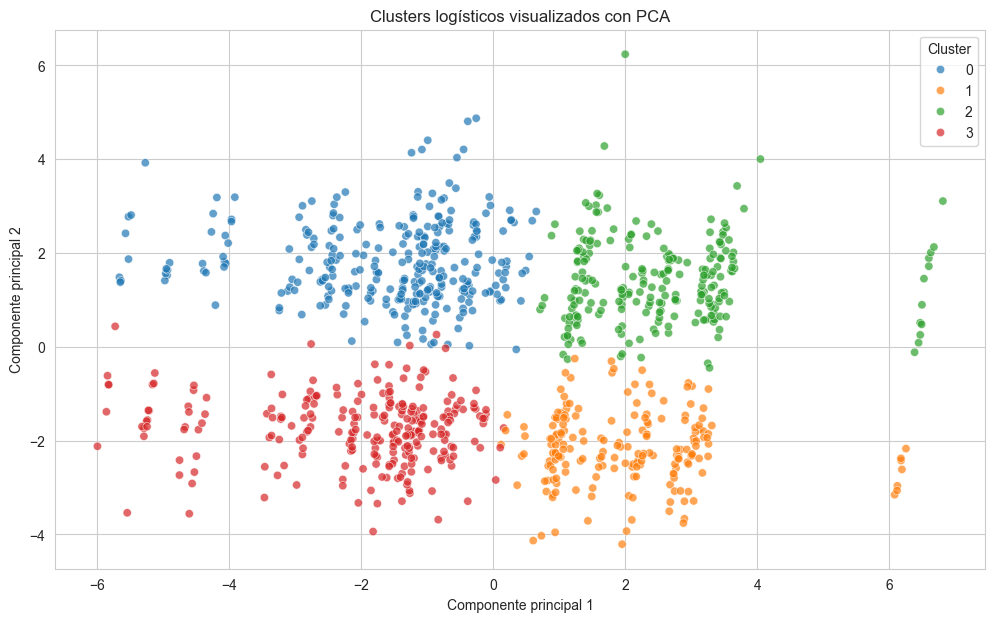

In [11]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["cluster"],
    palette="tab10",
    alpha=0.7
)

plt.title("Clusters logísticos visualizados con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")

plt.legend(title="Cluster")

plt.show()


## Análisis visual de clusters

La visualización permite observar:

- qué tan separados están los grupos;
- si existen clusters dominantes;
- si hay operaciones extremas;
- si aparecen perfiles operacionales diferenciados.

Esto ayuda a interpretar la estructura logística del dataset.


# 9. Caracterización de clusters

Ahora se analizarán las características promedio de cada cluster.


In [12]:
variables_analisis = [
    "riesgo_operacional",
    "distancia_km",
    "peso_kg",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg_recalculado",
    "riesgo_velocidad",
    "sobrecarga_kg",
    "vehiculo_exigido"
]

variables_analisis = [v for v in variables_analisis if v in df.columns]

perfil_clusters = df.groupby("cluster")[variables_analisis].mean()

perfil_clusters


,riesgo_operacional,distancia_km,peso_kg,velocidad_promedio_km_h,uso_capacidad_kg_recalculado,riesgo_velocidad,sobrecarga_kg,vehiculo_exigido
cluster,,,,,,,,
0,1720.754294,618.376721,10097.393770,51.204233,2.750141,35475.837065,0.973770,1.000000
1,688.923149,1541.622959,4908.136224,145.806286,0.437357,221910.827395,0.000000,0.040816
2,4448.068009,1580.556723,10230.245798,149.351041,2.787821,235005.665759,0.970588,1.000000
3,287.968805,608.759073,5283.707336,49.459352,0.467019,35191.389572,0.000000,0.042471


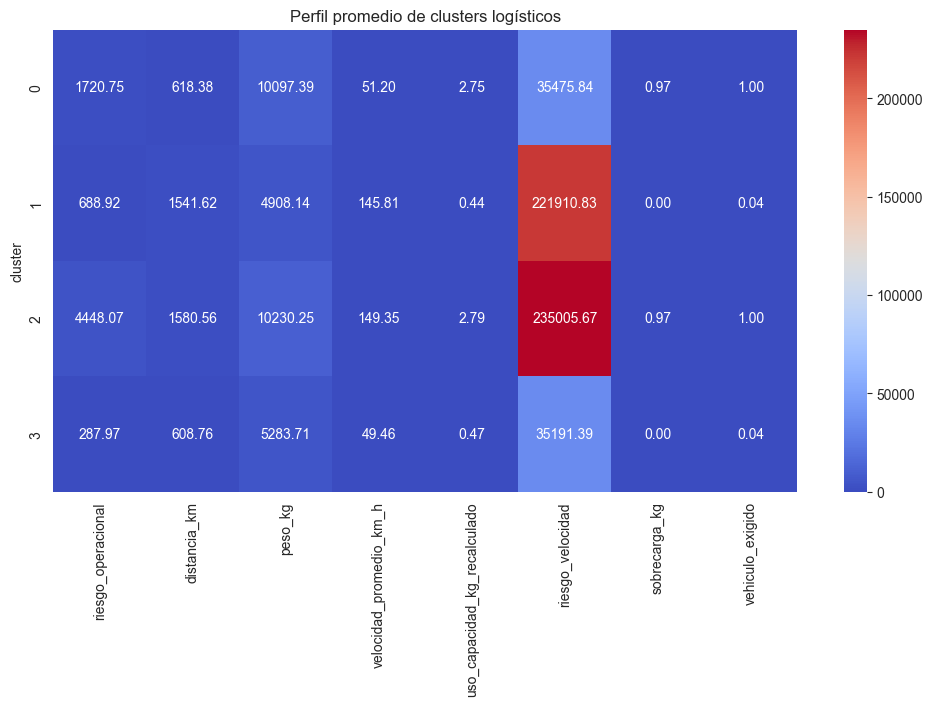

In [13]:
plt.figure(figsize=(12,6))

sns.heatmap(
    perfil_clusters,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Perfil promedio de clusters logísticos")

plt.show()


## Análisis de perfiles operacionales

Esta tabla permite interpretar qué representa cada cluster.

Por ejemplo, podrían aparecer grupos como:

- operaciones normales;
- rutas largas;
- operaciones de alta carga;
- vehículos exigidos;
- operaciones de riesgo extremo.

La interpretación final dependerá de los resultados obtenidos.


# 10. Distribución de riesgo operacional por cluster

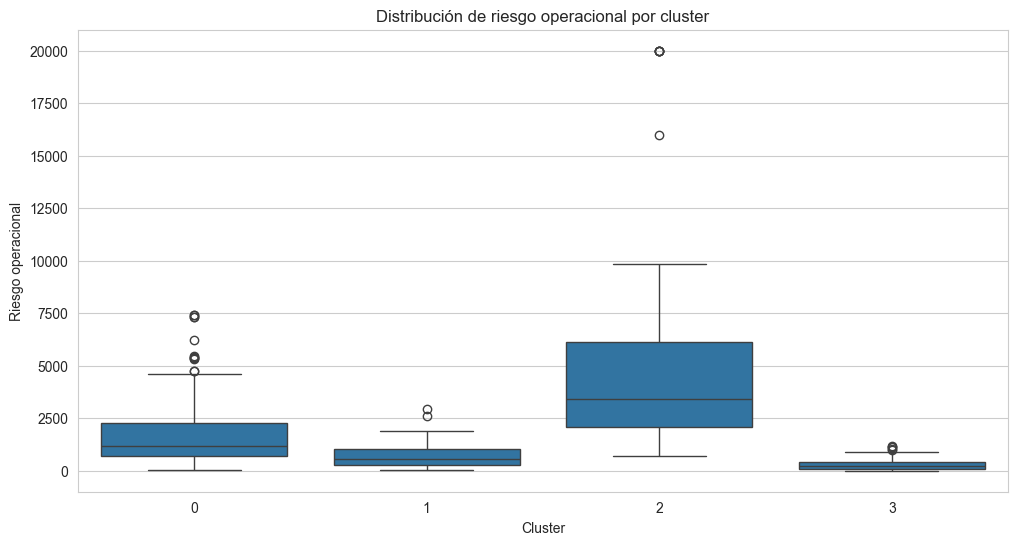

In [14]:
if "riesgo_operacional" in df.columns:

    plt.figure(figsize=(12,6))

    sns.boxplot(
        data=df,
        x="cluster",
        y="riesgo_operacional"
    )

    plt.title("Distribución de riesgo operacional por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Riesgo operacional")

    plt.show()


## Interpretación del riesgo por cluster

El boxplot permite comparar:

- dispersión;
- medianas;
- presencia de valores extremos;
- diferencias operacionales entre grupos.

Esto ayuda a validar si el clustering separó operaciones de distinto nivel de riesgo.


# 11. Variables categóricas por cluster

In [15]:
if "tipo_via" in df.columns:

    tabla_tipo_via = pd.crosstab(
        df["cluster"],
        df["tipo_via"],
        normalize="index"
    ) * 100

    display(tabla_tipo_via)

if "estado_vehiculo" in df.columns:

    tabla_estado = pd.crosstab(
        df["cluster"],
        df["estado_vehiculo"],
        normalize="index"
    ) * 100

    display(tabla_estado)


tipo_via,autopista,camino rural,ruta nacional,urbana
cluster,,,,
0,18.032787,16.393443,27.213115,38.360656
1,40.306122,13.775510,4.081633,41.836735
2,34.453782,12.605042,7.563025,45.378151
3,20.463320,15.444015,29.729730,34.362934


estado_vehiculo,en mantención,fuera de servicio,operativo
cluster,,,
0,14.098361,17.049180,68.852459
1,15.555556,9.444444,75.000000
2,14.285714,20.168067,65.546218
3,16.129032,12.096774,71.774194


## Interpretación de variables categóricas

El análisis de variables categóricas permite detectar:

- tipos de vía dominantes;
- estados de vehículo más frecuentes;
- patrones operacionales específicos por cluster.


# 12. Top variables explicativas del PCA

Se analizará qué variables aportan más a los componentes principales.


In [16]:
cargas_pca = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=variables_numericas
)

cargas_pca["PC1_abs"] = cargas_pca["PC1"].abs()

cargas_pca = cargas_pca.sort_values(
    by="PC1_abs",
    ascending=False
)

cargas_pca.head(15)


,PC1,PC2,PC1_abs
riesgo_velocidad_log,0.382130,-0.040850,0.382130
velocidad_promedio_km_h_log,0.371425,-0.042015,0.371425
riesgo_velocidad,0.368046,-0.038344,0.368046
velocidad_promedio_km_h,0.364758,-0.040713,0.364758
distancia_km,0.360681,-0.038174,0.360681
distancia_km_log,0.356357,-0.035711,0.356357
velocidad_alta,0.322819,-0.028484,0.322819
ruta_larga,0.273387,-0.022905,0.273387
uso_capacidad_kg_recalculado,0.041875,0.431843,0.041875
peso_kg,0.041306,0.320499,0.041306


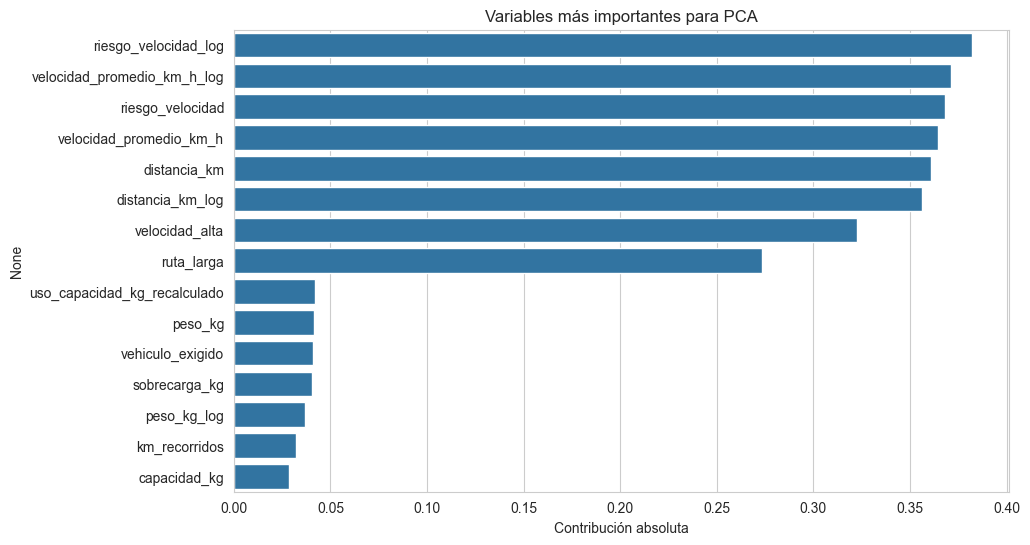

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=cargas_pca.head(15),
    x="PC1_abs",
    y=cargas_pca.head(15).index
)

plt.title("Variables más importantes para PCA")

plt.xlabel("Contribución absoluta")

plt.show()


## Interpretación del PCA

Las variables con mayor peso en los componentes principales son las que más explican las diferencias entre operaciones logísticas.

Estas variables ayudan a entender:

- qué factores generan segmentación;
- qué elementos diferencian los clusters;
- qué dimensiones explican más la operación logística.


# 13. Resumen de clusters encontrados

In [18]:
resumen_clusters = df.groupby("cluster").agg({
    "riesgo_operacional": ["mean", "max"],
    "distancia_km": "mean",
    "peso_kg": "mean",
    "uso_capacidad_kg_recalculado": "mean"
})

resumen_clusters


riesgo_operacional               distancia_km       peso_kg  \
                      mean           max         mean          mean   
cluster                                                               
0              1720.754294   7401.000000   618.376721  10097.393770   
1               688.923149   2928.280000  1541.622959   4908.136224   
2              4448.068009  20000.000000  1580.556723  10230.245798   
3               287.968805   1159.621836   608.759073   5283.707336   

        uso_capacidad_kg_recalculado  
                                mean  
cluster                               
0                           2.750141  
1                           0.437357  
2                           2.787821  
3                           0.467019

# 14. Conclusiones del notebook

En este notebook se aplicaron técnicas de aprendizaje no supervisado para segmentar operaciones logísticas.

Se utilizaron:

- PCA;
- KMeans;
- método del codo;
- silhouette score.

El análisis permitió identificar grupos naturales dentro de las operaciones, mostrando que el dataset contiene estructuras operacionales diferenciadas.

Los clusters encontrados podrían representar perfiles como:

- operaciones normales;
- rutas extensas;
- cargas elevadas;
- operaciones de alto riesgo;
- vehículos altamente exigidos.

Además, PCA permitió visualizar la estructura interna del dataset y reducir dimensionalidad para interpretar mejor los patrones encontrados.

Este análisis complementa el modelado supervisado realizado anteriormente, agregando una perspectiva exploratoria y estratégica sobre la operación logística.
